# Travel Insurance Prediction Analysis

### INTRODUCTION


**Goal:** A Tour & Travels Company offers a travel insurance package with Covid cover. They want to know which customers are likely to buy it. Our task is to predict if a customer will buy the insurance based on a set of independent variables (outlined below) 

**Data Source:** The data is from 2019 and includes information about almost 2000 customers.

**Metric:** Precision-Recall AUC [suitable for imbalanced data]

**Variables:** 

<u>Independent Variables:</u>

* **Age**: The customer's age
* **Employment Type**: The sector in which the customer works
* **GraduateOrNot**: Whether the customer graduated from college
* **AnnualIncome**: The customer's yearly income in Indian Rupees (rounded to the nearest 50 thousand)
* **FamilyMembers**: Number of people in the customer's family
* **ChronicDisease**: Whether the customer has a major disease like diabetes or high BP
* **FrequentFlyer**: Whether the customer booked air tickets at least 4 times in the last 2 years
* **EverTravelledAbroad**: Whether the customer has traveled to a foreign country

<u>Target Variable:</u>

* **TravelInsurance**: Whether the customer bought the insurance in 2019

**Notebook Structure:** 
1. Data Overview
2. Data Preparation
3. Exploratory Data Analysis 
4. Statistical Inference
5. Machine Learning Models
6. Conclusion and Improvements

### 1. DATA OVERVIEW

**1.1 Loading Libraries & Dataset**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.proportion import proportions_ztest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import warnings 
import phik 
from sklearn.exceptions import ConvergenceWarning
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_recall_curve
from scipy.stats import uniform
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, average_precision_score
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import randint, loguniform
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from itertools import combinations
import warnings; warnings.filterwarnings('ignore', module='sklearn')

df = pd.read_csv('TravelInsurancePrediction.csv')

df.head()

,Unnamed: 0,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,0,31,Government Sector,Yes,400000,6,1,No,No,0
1,1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


**1.2 Sample Size**

In [4]:
df.shape

(1987, 10)

This tell us that there are 1,987 rows of data and 10 columns which represent the 10 variables outlined above (including the Target Variable). 

**1.3 Variables**

In [5]:
df.columns

Index(['Unnamed: 0', 'Age', 'Employment Type', 'GraduateOrNot', 'AnnualIncome',
       'FamilyMembers', 'ChronicDiseases', 'FrequentFlyer',
       'EverTravelledAbroad', 'TravelInsurance'],
      dtype='object')

As expressed above, the dataset contains 10 variables. The column "Unnamed: 0" appears to be an index column from the original file and will be dropped in the "Data Preparation" section from further analysis.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1987 entries, 0 to 1986
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           1987 non-null   int64 
 1   Age                  1987 non-null   int64 
 2   Employment Type      1987 non-null   object
 3   GraduateOrNot        1987 non-null   object
 4   AnnualIncome         1987 non-null   int64 
 5   FamilyMembers        1987 non-null   int64 
 6   ChronicDiseases      1987 non-null   int64 
 7   FrequentFlyer        1987 non-null   object
 8   EverTravelledAbroad  1987 non-null   object
 9   TravelInsurance      1987 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 155.4+ KB


This tells us that the dataset contains 5 numerical variables (Age, AnnualIncome, FamilyMembers, ChronicDiseases and Travel Insurance) and 4 categorical variables (Employment Type, GraduateorNot, FrequentFlyer and EverTravelledAbroad).

### 2. DATA PREPARATION

**2.1 Removing Unnecessary Columns**

In [7]:
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,Government Sector,Yes,400000,6,1,No,No,0
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


I removed the Unnamed: 0 column, which was an unnecessary index column likely introduced during CSV import. 

**2.2 Missing Values**

In [8]:
df.isnull().sum()

Age                    0
Employment Type        0
GraduateOrNot          0
AnnualIncome           0
FamilyMembers          0
ChronicDiseases        0
FrequentFlyer          0
EverTravelledAbroad    0
TravelInsurance        0
dtype: int64

There are no missing values. 

**2.3 Duplicates**

In [9]:
df.duplicated().sum()

np.int64(738)

This tells us that 738 rows are duplicates. This seems a large number of duplicates for the dataset accounting for almost a third. Upon investigating the data, it seems that these are not duplicates but different customers who share similar characteristics. For this reason, I choose to retain these observations. 

However, this approach warrants careful consideration. The decision to keep duplicates could be criticised for introducing bias towards repeating patterns, risking model overfitting to these repeated feature combinations. Although, removing these rows would mean eliminating valid, independent observations from our analysis. This limitation is acknowledged, and future work could investigate duplicate features further.

**2.4 Column Rename**

In [10]:
df = df.rename(columns={"Employment Type": "EmploymentType"})

The column Employment Type was renamed to EmploymentType to remove the space and improve consistency. 

**2.5 Label Encoding**

In [11]:
warnings.filterwarnings('ignore', category=UserWarning)

binary_columns = ['GraduateOrNot', 'FrequentFlyer', 'EverTravelledAbroad', 'EmploymentType']
mapping = {'Yes': 1, 'No': 0, 'Government Sector': 1, 'Private Sector/Self Employed': 0}
df[binary_columns] = df[binary_columns].replace(mapping)

print("First few rows after encoding:")
print(df[binary_columns].head())

First few rows after encoding:
   GraduateOrNot  FrequentFlyer  EverTravelledAbroad  EmploymentType
0              1              0                    0               1
1              1              0                    0               0
2              1              0                    0               0
3              1              0                    0               0
4              1              1                    0               0


/var/folders/t4/tmhk5qkd4tq9kk98g0s9x0640000gn/T/ipykernel_77101/4277469075.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_columns] = df[binary_columns].replace(mapping)


I performed label encoding on the binary categorical variables (GraduateOrNot, FrequentFlyer, EverTravelledAbroad and EmploymentType) by converting the following into numerical format: 
* 'Yes' to 1 and 'No' to 0 for GraduateOrNot, FrequentFlyer, and EverTravelledAbroad
* "Government Sector" to 1 and "Private Sector/Self Employed" to 0 for EmploymentType

**2.6  Anomaly Detection**

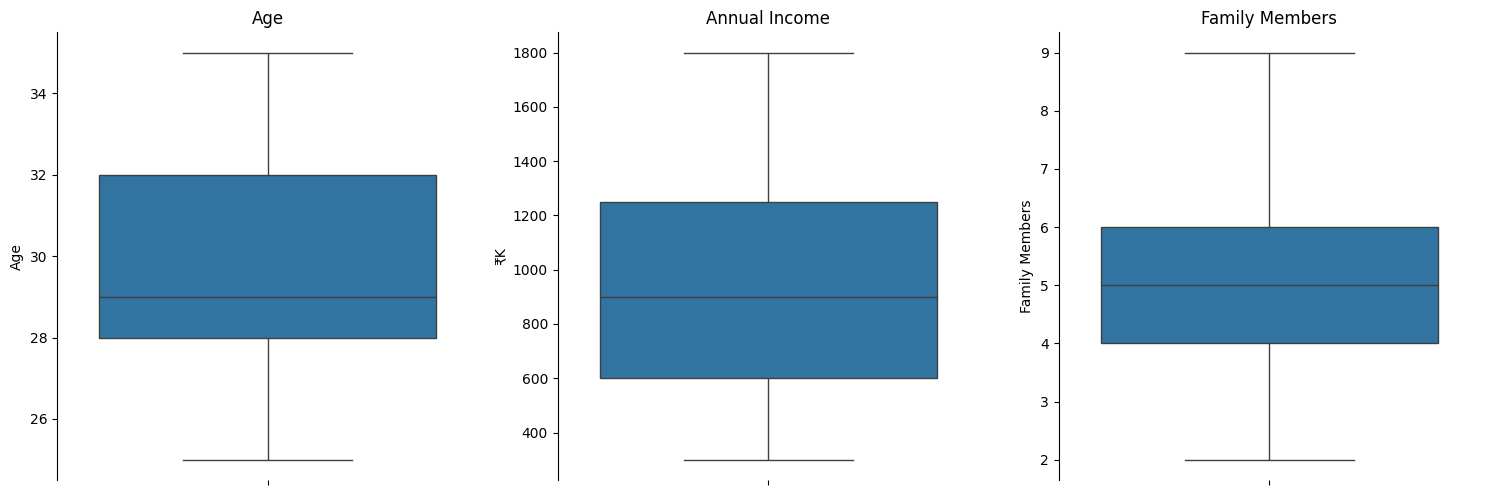

In [12]:
numerical_cols = ['Age', 'AnnualIncome', 'FamilyMembers']
_, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df[col]/1000 if col == 'AnnualIncome' else df[col], ax=axes[i])
    title = ''.join(' ' + c if c.isupper() and i > 0 else c for i, c in enumerate(col))
    axes[i].set(title=title, ylabel='₹K' if col == 'AnnualIncome' else title)
    [axes[i].spines[side].set_visible(False) for side in ['top', 'right', 'bottom']]

plt.tight_layout(); plt.show()

This tells us that there are no obvious anomalies beyond the whiskers of the boxplot on the non-binary numerical variables. For this reason, I do not plan to remove any anomalies. 

### 3. EXPLORATORY DATA ANALYSIS

**3.1  Statistical Summary**

In [13]:
pd.set_option('display.float_format', lambda x: '{:,.2f}'.format(x))
df.describe()

,Age,EmploymentType,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
count,"1,987.00","1,987.00","1,987.00","1,987.00","1,987.00","1,987.00","1,987.00","1,987.00","1,987.00"
mean,29.65,0.29,0.85,"932,762.96",4.75,0.28,0.21,0.19,0.36
std,2.91,0.45,0.36,"376,855.68",1.61,0.45,0.41,0.39,0.48
min,25.00,0.00,0.00,"300,000.00",2.00,0.00,0.00,0.00,0.00
25%,28.00,0.00,1.00,"600,000.00",4.00,0.00,0.00,0.00,0.00
50%,29.00,0.00,1.00,"900,000.00",5.00,0.00,0.00,0.00,0.00
75%,32.00,1.00,1.00,"1,250,000.00",6.00,1.00,0.00,0.00,1.00
max,35.00,1.00,1.00,"1,800,000.00",9.00,1.00,1.00,1.00,1.00


This statistical summary tells us about the numerical variables. Customers have an average age of approximately 30, with ages ranging from 25 to 35. Annual income varies widely, averaging around 932,762 Rupees, suggesting a diverse economic background. Most customers have between 2 and 9 family members, with a median of 5. About 28% of customers have chronic diseases. Notably, only around 36% of customers purchased travel insurance, indicating a class imbalance in the target variable.  

**3.2 Distribution of Variables**

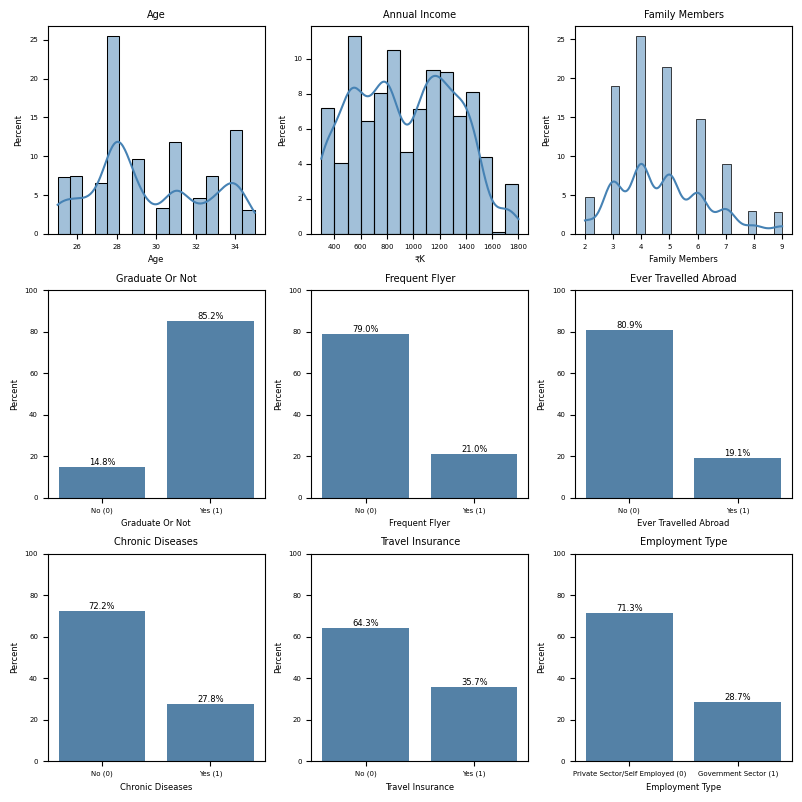

In [14]:
warnings.filterwarnings('ignore', category=UserWarning)

fig, axes = plt.subplots(3, 3, figsize=(8, 8))  
axes = axes.ravel()
plt.rcParams.update({'font.size': 6})  

binary_labels = {
    'GraduateOrNot': ['No (0)', 'Yes (1)'],
    'FrequentFlyer': ['No (0)', 'Yes (1)'],
    'EverTravelledAbroad': ['No (0)', 'Yes (1)'],
    'ChronicDiseases': ['No (0)', 'Yes (1)'],
    'TravelInsurance': ['No (0)', 'Yes (1)'],
    'EmploymentType': ['Private Sector/Self Employed (0)', 'Government Sector (1)']
}
for idx, var in enumerate(['Age', 'AnnualIncome', 'FamilyMembers'] + ['GraduateOrNot', 'FrequentFlyer', 'EverTravelledAbroad', 'ChronicDiseases', 'TravelInsurance', 'EmploymentType']):
    if idx < 3:  
        sns.histplot(data=df, x=var if var != 'AnnualIncome' else df[var]/1000, kde=True, 
                    color='steelblue', stat='percent', ax=axes[idx])
    else:
        percentages = df[var].value_counts().sort_index() / len(df) * 100
        sns.barplot(x=['0', '1'], y=percentages.values, color='steelblue', ax=axes[idx])
        [axes[idx].text(i, p, f'{p:.1f}%', ha='center', va='bottom', fontsize=6) for i, p in enumerate(percentages)]
        axes[idx].set_ylim(0, 100)
        axes[idx].set_xticklabels(binary_labels[var], rotation=0)

    title = ''.join(' ' + c if c.isupper() and i > 0 else c for i, c in enumerate(var))
    axes[idx].set_title(title, fontsize=7)
    axes[idx].set_xlabel(title if var != 'AnnualIncome' else '₹K', fontsize=6)
    axes[idx].set_ylabel('Percent', fontsize=6)
    axes[idx].tick_params(axis='both', labelsize=5)
plt.tight_layout()
plt.show()

Age shows a prominent peak at 28 years (approximately 25% of customers), with secondary peaks at ages 32 and 34 (each around 12-13%). Annual income presents a balanced distribution from 400K to 1800K, peaking around 600K (11%) and 800K (10%), while family size distribution centres strongly on 4 members (25%), with few families exceeding 6 members. Among the binary variables, education level stands out with 85.2% being graduates, predominantly non-frequent flyers (79%), and only 19.1% having international travel experience. Health-wise, 72.2% report no chronic diseases, and employment is dominated by the private sector/self-employed individuals (71.3%). Finally, there is a low travel insurance adoption rate at 35.7%, highlighting substantial untapped market potential. 

**3.3 Relationship between Variables and Travel Insurance**

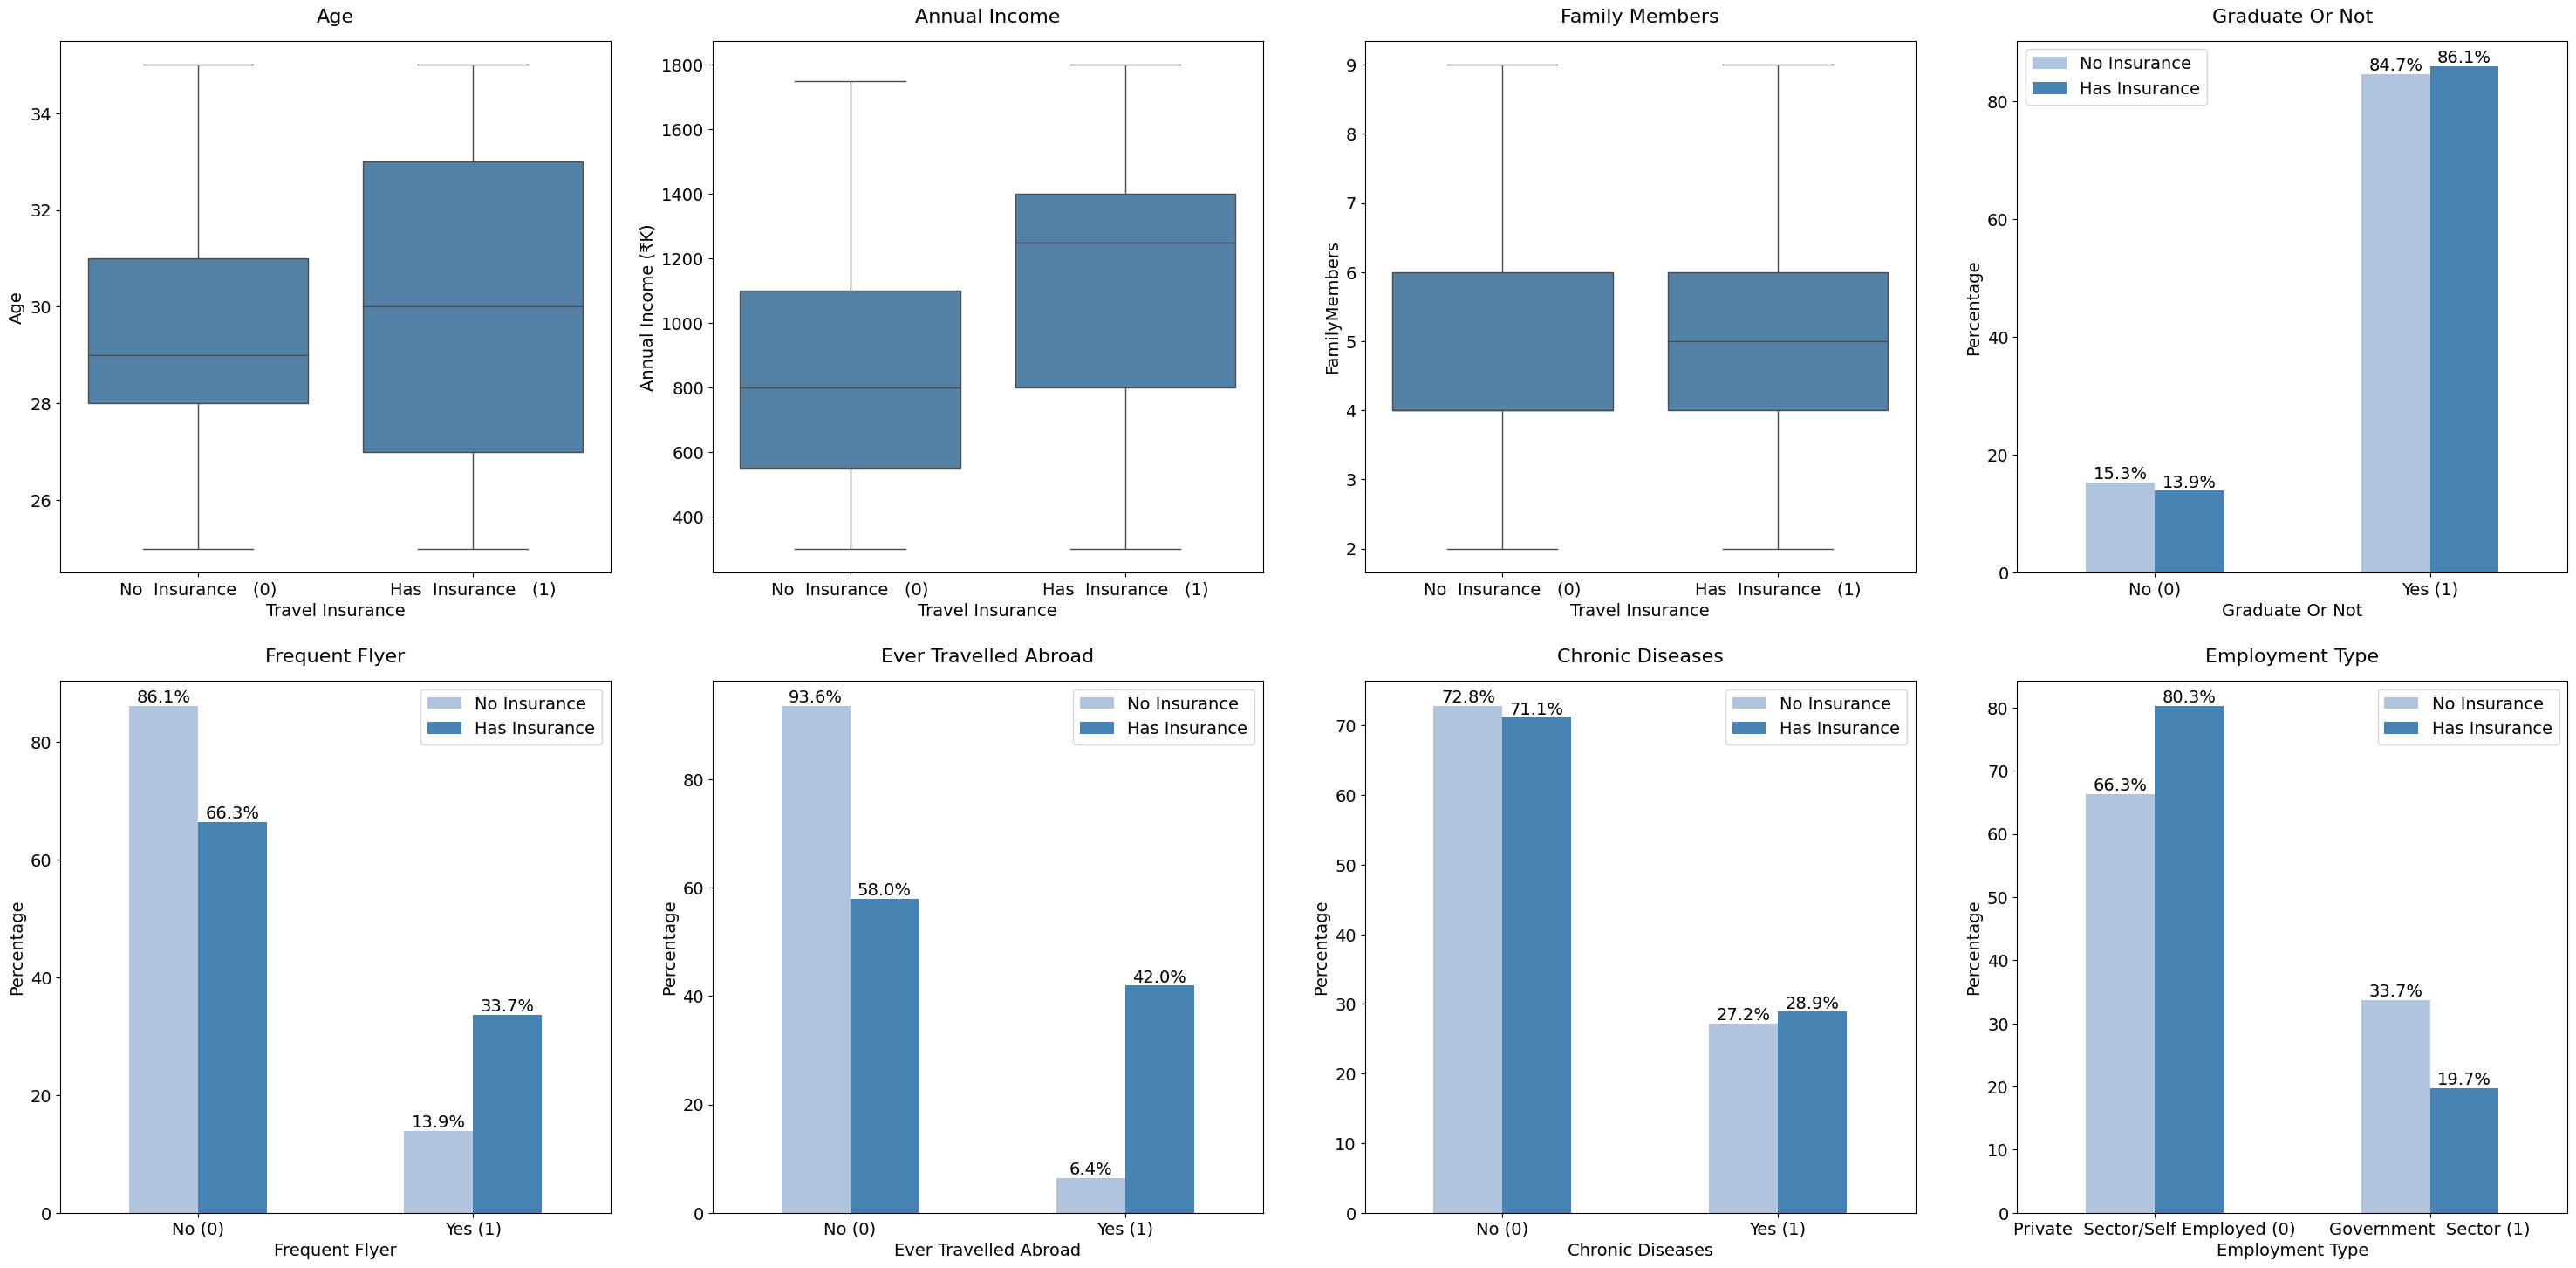

In [15]:
warnings.filterwarnings('ignore', category=UserWarning)

numerical_vars = ['Age', 'AnnualIncome', 'FamilyMembers']
binary_vars = ['GraduateOrNot', 'FrequentFlyer', 'EverTravelledAbroad', 'ChronicDiseases', 'EmploymentType']

formats = {
    'Age': 'Age', 'AnnualIncome': 'Annual Income', 'FamilyMembers': 'Family Members',
    'GraduateOrNot': ['Graduate Or Not', ['No (0)', 'Yes (1)']],
    'FrequentFlyer': ['Frequent Flyer', ['No (0)', 'Yes (1)']],
    'EverTravelledAbroad': ['Ever Travelled Abroad', ['No (0)', 'Yes (1)']],
    'ChronicDiseases': ['Chronic Diseases', ['No (0)', 'Yes (1)']],
    'EmploymentType': ['Employment Type', ['Private  Sector/Self Employed (0)', 'Government  Sector (1)']]
}

fig, axes = plt.subplots(2, 4, figsize=(30, 15))
axes = axes.ravel()

for idx, var in enumerate(numerical_vars + binary_vars):
    if idx < 3:
        sns.boxplot(x='TravelInsurance', y=var if var != 'AnnualIncome' else df[var]/1000,
                   data=df, ax=axes[idx], color='steelblue', showmeans=False)
        axes[idx].set_ylabel('Annual Income (₹K)' if var == 'AnnualIncome' else var, fontsize=14)
        axes[idx].set_xticklabels(['No  Insurance   (0)', 'Has  Insurance   (1)'], fontsize=14)
    else:
        cross_tab = pd.crosstab(df[var], df['TravelInsurance'])
        pct = cross_tab.div(cross_tab.sum(axis=0), axis=1) * 100
        pct.plot(kind='bar', ax=axes[idx], color=['lightsteelblue', 'steelblue'])
        [axes[idx].bar_label(container, fmt='%.1f%%', fontsize=14) for container in axes[idx].containers]
        axes[idx].legend(['No Insurance', 'Has Insurance'], fontsize=14)
        axes[idx].set_xticklabels(formats[var][1], rotation=0, fontsize=14)
    
    axes[idx].set_title(formats[var][0] if isinstance(formats[var], list) else formats[var], fontsize=16, pad=15)
    axes[idx].set_xlabel('Travel Insurance' if idx < 3 else formats[var][0] if isinstance(formats[var], list) else formats[var], fontsize=14)
    axes[idx].tick_params(axis='both', labelsize=14)
    if idx >= 3: axes[idx].set_ylabel('Percentage', fontsize=14)

plt.tight_layout(pad=4.0)
plt.show()

Income and age show positive correlations, with insurance holders being typically older (median ~30 vs 28 years) and wealthier (median ~1400K vs 800K). Travel behavior emerges as the strongest differentiator: among non-insured customers, 86.1% are non-frequent flyers and 93.6% have never traveled abroad, while insurance holders show significantly higher travel engagement (33.7% frequent flyers, 42% international experience). Employment type also plays a role, with private sector employees showing higher adoption rates (80.3% vs 66.3% non-holders), while factors like education, family size, and health status demonstrate minimal impact. This suggests that travel experience, income levels, and employment type are the key drivers of insurance adoption, providing clear indicators for market targeting. 

**3.4 Correlation Matrix**

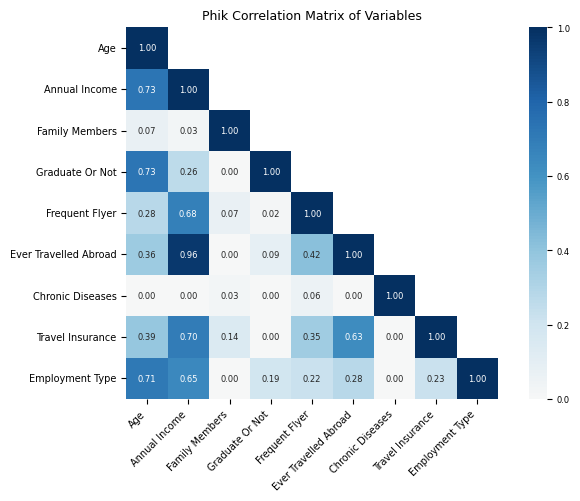

In [16]:
correlation_matrix = df[['Age', 'AnnualIncome', 'FamilyMembers', 'GraduateOrNot', 
                         'FrequentFlyer', 'EverTravelledAbroad', 'ChronicDiseases', 
                         'TravelInsurance', 'EmploymentType']].phik_matrix(interval_cols=['Age', 'AnnualIncome', 'FamilyMembers'])
mask = np.triu(np.ones_like(correlation_matrix), k=1)
formatted_labels = [re.sub(r'(?<!^)(?=[A-Z])', ' ', col) for col in correlation_matrix.columns]
plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix,
            mask=mask, 
            annot=True,
            cmap='RdBu',
            center=0,
            fmt='.2f',
            square=True,
            xticklabels=formatted_labels,
            yticklabels=formatted_labels)
plt.title('Phik Correlation Matrix of Variables', fontsize=9)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

This reveals that Travel Insurance uptake has the strongest positive correlations with Annual Income (0.70), Ever Travelled Abroad (0.63), followed by Age (0.39) and Frequent Flyer status (0.35), while other variables show very weak correlations (less than 0.23). 


**3.5 Variance Inflation Factor**

In [17]:
numerical_vars = ['Age', 'AnnualIncome', 'FamilyMembers']
binary_vars = ['GraduateOrNot', 'FrequentFlyer', 'EverTravelledAbroad', 'ChronicDiseases', 'EmploymentType']
features = numerical_vars + binary_vars

def calculate_vif(df, features):
    vif_data = pd.DataFrame()
    vif_data["Features"] = features
    vif_data["VIF"] = [variance_inflation_factor(df[features].values, i) 
                       for i in range(len(features))]
    return vif_data.sort_values('VIF', ascending=False)

vif_df = calculate_vif(df, features)
display(vif_df)

,Features,VIF
0,Age,19.68
1,AnnualIncome,10.69
2,FamilyMembers,9.19
3,GraduateOrNot,6.90
7,EmploymentType,1.67
5,EverTravelledAbroad,1.64
4,FrequentFlyer,1.48
6,ChronicDiseases,1.39


The Variance Inflation Factor (VIF) analysis reveals high multicollinearity among Age, Annual Income, Family Members and Graduate or Not variables, with VIF scores exceeding the typical acceptable threshold of 5. However, given their strong business relevance to travel insurance prediction and potential importance for model performance, I have opted to retain all features rather than remove them to address the multicollinearity.

### 4. STATISTICAL INFERENCE

**4.1 Target Population**

The target population are 2000 customers between the ages of 25 and 35 who were offered travel insurance by a Tour & Travels Company in 2019. 

**4.2 Statistical Hypotheses**

Based on the EDA, I have chosen to examine the relationship between the top 3 positively correlated independent variables and Travel Insurance: 

<u>Hypothesis 1: Age</u>

* **Null Hypothesis (H0):** There is no difference in mean age between insurance purchasers and non-purchasers. 
* **Alternative Hypothesis (H1):** Insurance purchasers have different mean age than non-purchasers. 

<u>Hypothesis 2: Annual Income</u>

* **Null Hypothesis (H0):** There is no difference in annual income between insurance purchasers and non-purchasers. 
* **Alternative Hypothesis (H1):** Insurance purchasers have higher annual income than non-purchasers. 

<u>Hypothesis 3: Ever Travelled Abroad</u>

* **Null Hypothesis (H0):** There is no difference in insurance purchase rates between those who have and haven't traveled abroad. 
* **Alternative Hypothesis (H1):** Those who have traveled abroad have higher insurance purchase rates. 

**4.3 Statistical Testing**

The following analysis examines each hypothesis through statistical testing, including significance levels, appropriate test selection, and confidence interval construction.

**4.3.1 <u>Hypothesis 1: Age</u>**

* **Significance level:** α = 0.05 (5%)

* **Test Selection:** Welch's t-test (tests for differences between means of two independent groups (insurance purchasers vs. non purchasers))

* **Assumptions:** (1) Does not require equal variances (to be verified below using Levene's test) and (2) requires data normality (to be verified below using Shapiro-Wilk test).

* **Testing Assumptions:**

<u>1. Unequal Variances: Levene's Test</u>

In [18]:
stat, p = stats.levene(df[df['TravelInsurance']==1]['Age'], df[df['TravelInsurance']==0]['Age'])
print(f"Levene: stat={stat:.4f}, p={p:.4f}")

Levene: stat=125.9011, p=0.0000


The test result tell us that the variances are significanlty unequal between the two groups because the p value is very small. Practically, this means that the variability of age is different between the insurance purchasers and non-purchasers. Therefore, this assumption is met. 

<u>2. Data Normality: Shapiro-Wilk Test</u>

In [19]:
s1,p1 = stats.shapiro(df[df['TravelInsurance']==1]['Age'])
s2,p2 = stats.shapiro(df[df['TravelInsurance']==0]['Age'])
print(f"Shapiro: Ins(p={p1:.4f}), NoIns(p={p2:.4f})")

Shapiro: Ins(p=0.0000), NoIns(p=0.0000)


The test results tell us that the groups are not normally distributed due to the small p values but according to the Central Limit Theorem, with our large sample size (n=1987), the sampling distribution of means will approximate a normal distribution regardless of the underlying distribution, allowing us to proceed with parametric testing.

**Welch's t-test:**

In [20]:
t_stat, p_val = stats.ttest_ind(df[df['TravelInsurance']==1]['Age'], df[df['TravelInsurance']==0]['Age'], equal_var=False, alternative='two-sided')
print(f"Welch's t-test: stat={t_stat:.4f}, p={p_val:.4f}")

Welch's t-test: stat=2.5542, p=0.0108


The Welch's t-test results tell us that there is a significant difference in mean age between insurance purchasers and non-purchasers. The positive t-statistic suggests that insurance purchasers (group 1) tend to be older than non-purchasers (group 0). 

**Confidence Intervals**

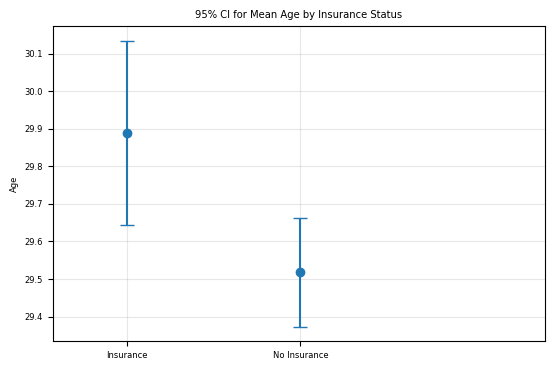

95% Confidence Intervals:
Insurance Purchasers: (29.64, 30.13)
Non-Purchasers: (29.27, 29.66)


In [21]:
age_ins, age_no_ins = df[df['TravelInsurance']==1]['Age'], df[df['TravelInsurance']==0]['Age']
mean_ins, ci_ins = np.mean(age_ins), stats.t.ppf(0.975, len(age_ins)-1) * stats.sem(age_ins)
mean_no_ins, ci_no_ins = np.mean(age_no_ins), stats.t.ppf(0.975, len(age_no_ins)-1) * stats.sem(age_no_ins)

plt.figure(figsize=(8,4))
plt.xlim(-0.2, 0.2)
plt.errorbar([-0.14, 0.0013], [mean_ins, mean_no_ins], yerr=[ci_ins, ci_no_ins], fmt='o', capsize=5)
plt.xticks([-0.14, 0.0013], ['Insurance', 'No Insurance'])
plt.title('95% CI for Mean Age by Insurance Status')
plt.ylabel('Age')
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=3)
plt.subplots_adjust(right=0.7) 
plt.show()

print(f"95% Confidence Intervals:\nInsurance Purchasers: ({mean_ins-ci_ins:.2f}, {mean_ins+ci_ins:.2f})\nNon-Purchasers: ({mean_no_ins-ci_ins:.2f}, {mean_no_ins+ci_no_ins:.2f})")

The interval plot tells us that we are 95% confident the true mean of age of insurance purchasers and non-purchasers falls within the ranges above. The confidence intervals do not overlap. There is a wider interval for insurance purchasers than non-purchasers, suggesting slightly more uncertainty in our estimate of their true mean age. 

**4.3.2 <u>Hypothesis 2: Annual Income</u>**

* **Significance level:** α = 0.05 (5%)

* **Test Selection:** Mann-Whitney U Test (compares the probability of getting a higher annual income from insurance purchasers vs. non-purchasers)

* **Assumptions:** (1) continuous data (met as income is continuous),(2) the distribution shape does not need to be normal (met as distribution is multi-model as seen above in EDA), and (3) independent groups (met as each person either has insurance or not). 

**Mann-Whitney U Test** 

In [22]:
stat, p = stats.mannwhitneyu(df[df['TravelInsurance']==1]['AnnualIncome'], df[df['TravelInsurance']==0]['AnnualIncome'], alternative='greater')
print(f"Mann-Whitney U test: stat={stat:.4f}, p={p:.4f}")

Mann-Whitney U test: stat=670230.5000, p=0.0000


The Mann-Whitney U test reveals a significant difference between the income distributions of insurance purchasers and non-purchasers. The large U statistic indicates that individuals who purchase travel insurance tend to have higher incomes compared to those who do not purchase insurance.

**Confidence Intervals**

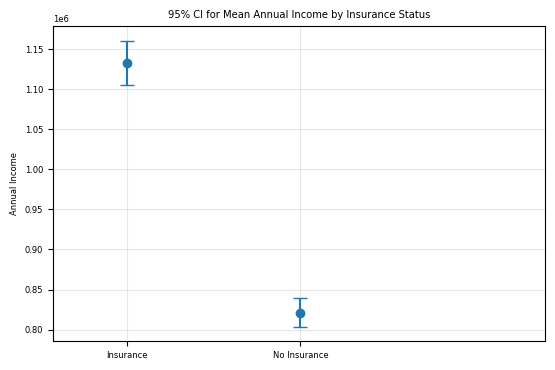

95% Confidence Intervals:
Insurance Purchasers: (1105620.16, 1160858.71)
Non-Purchasers: (803243.69, 839356.16)


In [23]:
income_ins = df[df['TravelInsurance']==1]['AnnualIncome']
income_no_ins = df[df['TravelInsurance']==0]['AnnualIncome']
mean_ins, ci_ins = np.mean(income_ins), stats.t.ppf(0.975, len(income_ins)-1) * stats.sem(income_ins)
mean_no_ins, ci_no_ins = np.mean(income_no_ins), stats.t.ppf(0.975, len(income_no_ins)-1) * stats.sem(income_no_ins)

plt.figure(figsize=(8,4))
plt.xlim(-0.2, 0.2)
plt.errorbar([-0.14, 0.0013], [mean_ins, mean_no_ins], yerr=[ci_ins, ci_no_ins], fmt='o', capsize=5)
plt.xticks([-0.14, 0.0013], ['Insurance', 'No Insurance'])
plt.title('95% CI for Mean Annual Income by Insurance Status')
plt.ylabel('Annual Income')
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=3)
plt.subplots_adjust(right=0.7)
plt.show()

print(f"95% Confidence Intervals:\nInsurance Purchasers: ({mean_ins-ci_ins:.2f}, {mean_ins+ci_ins:.2f})")
print(f"Non-Purchasers: ({mean_no_ins-ci_no_ins:.2f}, {mean_no_ins+ci_no_ins:.2f})")

The interval plot tells us that we are 95% confident that for insurance purchasers, the true mean income falls between 1,105,620.16 and 1,160,858.71 Rupees, while for non-purchasers, the interval ranges from 803,243.69 to 839,356.16 Rupees. The complete lack of overlap between these intervals, combined with their relatively narrow widths, indicates a clear and substantial difference in income between the groups. 

**4.3.3 <u>Hypothesis 3: Ever Travelled Abroad</u>**

* **Significance level:** α = 0.05 (5%)

* **Test selection:** Two-Sample Proportion Z-test (compares the proportion of insurance purchasers between those who have and have not travelled abroad)

* **Assumptions:** (1) binary outcome (met as there is a yes/no answer) and (2) large enough sample size (this is met as more than 10 in both groups). 

**Two-Sample Proportion Z-test**

In [24]:
s = [df[df['EverTravelledAbroad']==1]['TravelInsurance'].sum(), df[df['EverTravelledAbroad']==0]['TravelInsurance'].sum()]
n = [df[df['EverTravelledAbroad']==1].shape[0], df[df['EverTravelledAbroad']==0].shape[0]]
stat, p = proportions_ztest(s, n, alternative='larger')
print(f"Two-sample z-test: stat={stat:.4f}, p={p:.4f}")

Two-sample z-test: stat=19.3095, p=0.0000


The Two-sSmple Proportion Z-test reveals a significant difference in insurance purchase rates between individuals who have traveled abroad and those who have not. The large positive z-statistic indicates that people who have traveled abroad are much more likely to purchase travel insurance compared to those who have never traveled abroad.

**Confidence Interval:** 

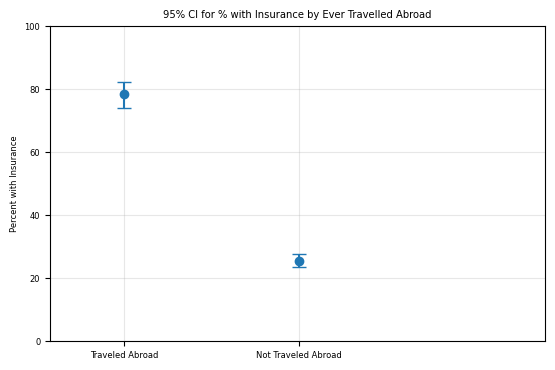

95% Confidence Intervals:
Traveled Abroad: (74.0%, 82.3%)
Not Traveled Abroad: (23.6%, 27.8%)


In [25]:
x_pos = [-0.14, 0.0013]
labels = ['Traveled Abroad', 'Not Traveled Abroad']
props, errs = zip(*[
    (p := df[df['EverTravelledAbroad']==g]['TravelInsurance'].mean() * 100,
     [p - (ci := np.array(sm.stats.proportion_confint(
         df[df['EverTravelledAbroad']==g]['TravelInsurance'].sum(),
         df[df['EverTravelledAbroad']==g].shape[0],
         alpha=0.05, method='wilson')) * 100)[0],
      ci[1] - p])
    for g in [1, 0]
])
plt.figure(figsize=(8,4))
plt.xlim(-0.2, 0.2)
plt.errorbar(x_pos, props, yerr=np.array(errs).T, fmt='o', capsize=5)
plt.xticks(x_pos, labels)
plt.title('95% CI for % with Insurance by Ever Travelled Abroad')
plt.ylabel('Percent with Insurance')
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=3)
plt.subplots_adjust(right=0.7)
plt.show()

print("95% Confidence Intervals:")
for l, p, (lo, up) in zip(labels, props, errs):
    print(f"{l}: ({p-lo:.1f}%, {p+up:.1f}%)")

The interval plot tells us that we are 95% confident that, for those who have traveled abroad, the true proportion with insurance falls between 74.0% and 82.3%, while for those who have not traveled abroad, the interval ranges from 23.6% to 27.8%. The lack of overlap between these intervals indicates a clear difference in insurance purchase rates between the groups. The traveled abroad group has a wider interval and more uncertainty in the estimate (8.3 percentage difference) than the note traveled abroad group which has a narrower interval (4.2 percentage difference). 

### 5. MACHINE LEARNING MODELS

**5.1 Splitting the Data**

In [26]:
X = df.drop(['TravelInsurance'], axis=1)
y = df['TravelInsurance']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
) 

**5.2 Model Selection**

In [27]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier() 
}

Next I train and evaluate the following models: (1) Logistic regression, (2) Random Forest (3) Support Vector Machine (SVM) and (4) K-nearest Neighbours (KNN). 

**5.3 Model Pipeline**

In [28]:
pipelines = {}
for name, model in models.items(): 
    pipelines[name] = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])

Here I have implemented a preprocessing pipeline that combines feature scaling and model training into a single automated workflow. 

**5.4 Model Fitting**

In [29]:
results = []
for name, pipeline in pipelines.items():  
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_scores = pipeline.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='binary', zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred, average='binary', zero_division=0),
        'ROC AUC': roc_auc_score(y_test, y_scores),
        'PR AUC': average_precision_score(y_test, y_scores)
    })

results_df = pd.DataFrame(results)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Logistic Regression,0.76,0.75,0.51,0.61,0.76,0.68
1,Random Forest,0.80,0.79,0.59,0.67,0.76,0.76
2,SVM,0.78,0.79,0.53,0.63,0.75,0.69
3,K-Nearest Neighbors,0.74,0.66,0.58,0.62,0.73,0.65


Focusing on the target metric PR AUC, Random Forest leads with 76%, demonstrating the best balance between precision and recall for this task. SVM and Logistic Regression follow with PR AUC scores of 69% and 68% respectively, while K-Nearest Neighbors trails at 65%. 

**5.4.1 Comparison of PR AUC Model Performance**

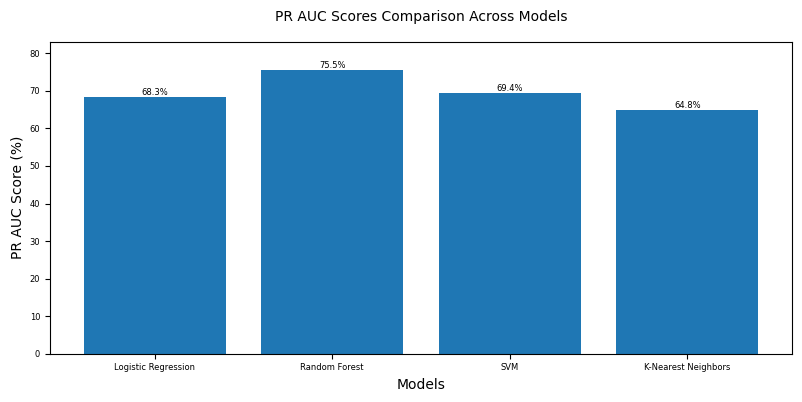

In [30]:
plt.figure(figsize=(8, 4))
models = results_df['Model']
pr_auc_scores = results_df['PR AUC']
pr_auc_percentages = pr_auc_scores * 100
bars = plt.bar(models, pr_auc_percentages)
plt.title('PR AUC Scores Comparison Across Models', fontsize=10, pad=15)
plt.xlabel('Models', fontsize=10)
plt.ylabel('PR AUC Score (%)', fontsize=10) 
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom')
plt.ylim(0, max(pr_auc_percentages) * 1.1)
plt.tight_layout()
plt.show()

The bar chart visualises PR AUC scores across models, with Random Forest achieving the highest performance at 76%, followed by SVM (69%) and Logistic Regression (68%), while K-Nearest Neighbors shows the lowest performance at 64%, indicating Random Forest's superior ability to balance precision and recall in predicting travel insurance purchases.

**5.4.2 Confusion Matrices**

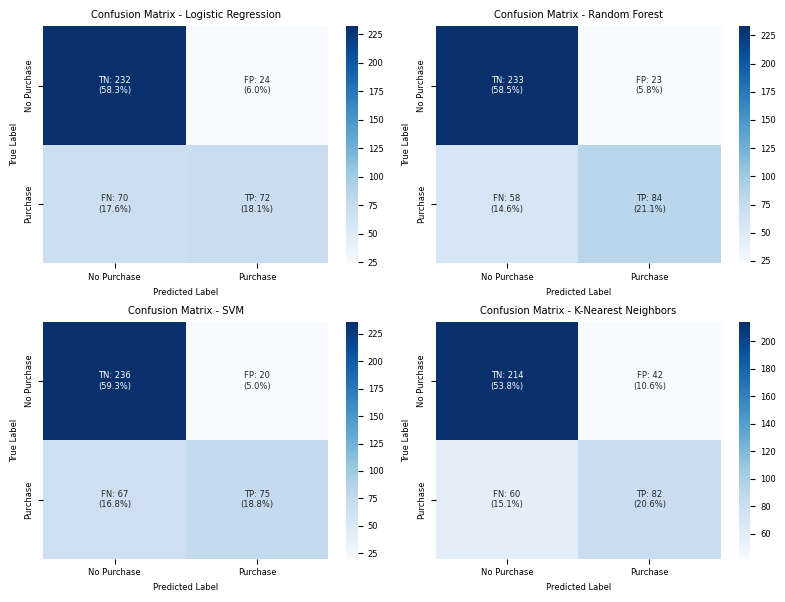

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))  
axes = axes.ravel()
for idx, (name, pipeline) in enumerate(pipelines.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    total = np.sum(cm)
    cm_percentages = cm / total * 100
    labels = np.array([
        [f'TN: {cm[0,0]}\n({cm_percentages[0,0]:.1f}%)', f'FP: {cm[0,1]}\n({cm_percentages[0,1]:.1f}%)'],
        [f'FN: {cm[1,0]}\n({cm_percentages[1,0]:.1f}%)', f'TP: {cm[1,1]}\n({cm_percentages[1,1]:.1f}%)']
    ])
    
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
                xticklabels=['No Purchase', 'Purchase'],
                yticklabels=['No Purchase', 'Purchase'],
                ax=axes[idx])
    
    axes[idx].set_title(f'Confusion Matrix - {name}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

Comparing the confusion matrices, Random Forest demonstrates the best overall performance with the highest true positive rate (21.1%, 84 purchases) and a strong true negative rate (58.5%, 233 non-purchases), while maintaining the lowest false predictions. SVM and Logistic Regression show similar patterns but with slightly lower performance, while K-Nearest Neighbors lags behind with the highest false positive rate (10.6%) and lowest true negative rate (53.8%).

**5.5 Hyperparameter Tuning**

I will now hyperparameter these models to further enhance model performance and display the best parameters for each model below, alongside a comparison of the default model performance vs the tuned model performance. Through iterative testing of various parameter combinations, I identified the optimal hyperparameters for each model that yielded the best performance. 

In [32]:
models_default_tuned = results_df.copy()
models_default_tuned.columns = ['Model'] + [f'Default {col}' for col in results_df.columns[1:]]

param_grids = {
    'Logistic Regression': {'classifier__C': [0.1, 1.0, 10.0], 'classifier__penalty': ['l1', 'l2'], 
                           'classifier__solver': ['liblinear', 'saga'], 'classifier__class_weight': ['balanced', {0:1, 1:1.5}, None]},
    'Random Forest': {'classifier__n_estimators': [100, 200], 'classifier__class_weight': [None, 'balanced']},
    'SVM': {'classifier__C': [1.0, 2.0, 5.0], 'classifier__kernel': ['rbf', 'poly'], 
            'classifier__gamma': ['scale', 'auto'], 'classifier__class_weight': ['balanced', {0:1, 1:1.5}]},
    'K-Nearest Neighbors': {'classifier__n_neighbors': [5, 7, 9, 11], 'classifier__weights': ['distance'],
                           'classifier__p': [1, 2], 'classifier__leaf_size': [20, 30, 40]}
}

scoring = {metric: metric if metric != 'pr_auc' else 'average_precision' 
          for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tuned_results = []

for name, pipeline in pipelines.items():
    search = RandomizedSearchCV(pipeline, param_grids[name], cv=skf, n_iter=20, 
                              scoring=scoring, refit='pr_auc', random_state=42).fit(X_train, y_train)
    tuned_results.append({
        'Model': name,
        'Tuned Accuracy': search.cv_results_['mean_test_accuracy'][search.best_index_],
        'Tuned Precision': search.cv_results_['mean_test_precision'][search.best_index_],
        'Tuned Recall': search.cv_results_['mean_test_recall'][search.best_index_],
        'Tuned F1 Score': search.cv_results_['mean_test_f1'][search.best_index_],
        'Tuned ROC AUC': search.cv_results_['mean_test_roc_auc'][search.best_index_],
        'Tuned PR AUC': search.cv_results_['mean_test_pr_auc'][search.best_index_]
    })
    print(f"\n{name}: {search.best_params_}")

final_comparison = pd.merge(models_default_tuned, pd.DataFrame(tuned_results), on='Model')
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'PR AUC']
improvements = pd.DataFrame({'Model': final_comparison['Model']})

for metric in metrics:
    improvements[f'{metric} Improvement'] = (
        final_comparison[f'Tuned {metric}'] - final_comparison[f'Default {metric}']
    ).round(3)

print("\nModel Performance Comparison (Default vs Tuned):")
display(final_comparison)
print("\nImprovements after tuning:")
display(improvements)


Logistic Regression: {'classifier__solver': 'saga', 'classifier__penalty': 'l2', 'classifier__class_weight': None, 'classifier__C': 10.0}

Random Forest: {'classifier__n_estimators': 200, 'classifier__class_weight': None}

SVM: {'classifier__kernel': 'rbf', 'classifier__gamma': 'scale', 'classifier__class_weight': {0: 1, 1: 1.5}, 'classifier__C': 1.0}

K-Nearest Neighbors: {'classifier__weights': 'distance', 'classifier__p': 1, 'classifier__n_neighbors': 9, 'classifier__leaf_size': 40}

Model Performance Comparison (Default vs Tuned):


,Model,Default Accuracy,Default Precision,Default Recall,Default F1 Score,Default ROC AUC,Default PR AUC,Tuned Accuracy,Tuned Precision,Tuned Recall,Tuned F1 Score,Tuned ROC AUC,Tuned PR AUC
0,Logistic Regression,0.76,0.75,0.51,0.61,0.76,0.68,0.77,0.79,0.48,0.60,0.77,0.72
1,Random Forest,0.80,0.79,0.59,0.67,0.76,0.76,0.79,0.74,0.63,0.68,0.79,0.77
2,SVM,0.78,0.79,0.53,0.63,0.75,0.69,0.80,0.81,0.59,0.68,0.80,0.76
3,K-Nearest Neighbors,0.74,0.66,0.58,0.62,0.73,0.65,0.78,0.73,0.61,0.67,0.76,0.68



Improvements after tuning:


,Model,Accuracy Improvement,Precision Improvement,Recall Improvement,F1 Score Improvement,ROC AUC Improvement,PR AUC Improvement
0,Logistic Regression,0.00,0.04,-0.03,-0.01,0.01,0.04
1,Random Forest,-0.01,-0.04,0.04,0.01,0.03,0.02
2,SVM,0.02,0.02,0.06,0.05,0.05,0.07
3,K-Nearest Neighbors,0.04,0.07,0.04,0.05,0.03,0.03


Focusing on the PR AUC metric, SVM showed the largest improvement (+0.07) after tuning, increasing from 0.69 to 0.76. Logistic Regression improved by 0.04 (0.68 to 0.72), while both Random Forest and K-Nearest Neighbors had smaller gains (+0.02 and +0.03 respectively). Despite these improvements, Random Forest maintained the highest overall PR AUC score (0.77), closely followed by SVM (0.76), indicating these two models are most effective at balancing precision and recall in predicting travel insurance purchases.

**5.5.1 PR AUC Comparison Before and After Tuning**

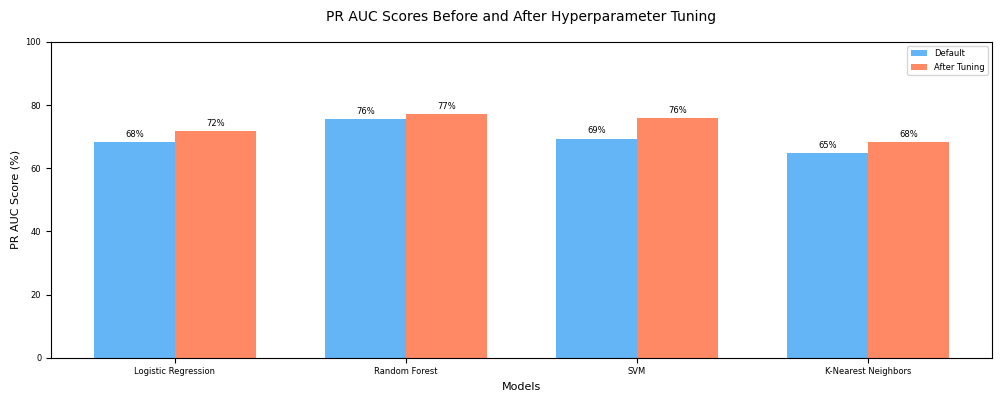

In [33]:
plt.figure(figsize=(10, 4))

models = final_comparison['Model']
default_scores = final_comparison['Default PR AUC'] * 100  
tuned_scores = final_comparison['Tuned PR AUC'] * 100     

x = np.arange(len(models))
width = 0.35
plt.bar(x - width/2, default_scores, width, label='Default', color='#2196F3', alpha=0.7)
plt.bar(x + width/2, tuned_scores, width, label='After Tuning', color='#FF5722', alpha=0.7)

plt.title('PR AUC Scores Before and After Hyperparameter Tuning', fontsize=10, pad=15)
plt.xlabel('Models', fontsize=8)
plt.ylabel('PR AUC Score (%)', fontsize=8) 
plt.xticks(x, models, ha='center')  
plt.ylim(0, 100) 

for i, v in enumerate(default_scores):
    plt.text(i - width/2, v + 1, f'{v:.0f}%', ha='center', va='bottom')
for i, v in enumerate(tuned_scores):
    plt.text(i + width/2, v + 1, f'{v:.0f}%', ha='center', va='bottom')
plt.legend()
plt.tight_layout()
plt.show()

The shows PR AUC scores before and after tuning, with Random Forest leading at 77% (1% gain), followed by SVM's notable improvement from 69% to 76%. Logistic Regression and K-Nearest Neighbors show smaller gains, improving to 72% and 68% respectively, with SVM demonstrating the most significant benefit from tuning.

**5.8 Model Ensembling**

In [34]:
tuned_models = {}
for name, pipeline in pipelines.items():
    search = RandomizedSearchCV(pipeline, param_grids[name], cv=skf, n_iter=20, 
                              scoring=scoring, refit='pr_auc', random_state=42).fit(X_train, y_train)
    tuned_models[name] = search.best_estimator_

def get_cv_results(model_name, cv_results):
    return {
        'Model': model_name,
        'Accuracy': cv_results['test_accuracy'].mean(),
        'Precision': cv_results['test_precision'].mean(),
        'Recall': cv_results['test_recall'].mean(),
        'F1 Score': cv_results['test_f1'].mean(),
        'ROC AUC': cv_results['test_roc_auc'].mean(),
        'PR AUC': cv_results['test_pr_auc'].mean()
    }
ensemble_results = []

for name, model in tuned_models.items():
    cv_results = cross_validate(model, X_train, y_train, scoring=scoring, cv=skf)
    ensemble_results.append(get_cv_results(name, cv_results))

for r in range(2, len(tuned_models) + 1):
    for combo in combinations(tuned_models.keys(), r):
        voter = VotingClassifier(
            estimators=[(name, tuned_models[name]) for name in combo],
            voting='soft'
        )
        cv_results = cross_validate(voter, X_train, y_train, scoring=scoring, cv=skf)
        ensemble_results.append(get_cv_results(f"Voting_{'+'.join(combo)}", cv_results))

ensemble_results_df = pd.DataFrame(ensemble_results).round(2)
display(ensemble_results_df.sort_values('PR AUC', ascending=False))

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
4,Voting_Logistic Regression+Random Forest,0.82,0.84,0.60,0.70,0.80,0.78
10,Voting_Logistic Regression+Random Forest+SVM,0.82,0.85,0.59,0.70,0.80,0.78
1,Random Forest,0.79,0.74,0.63,0.68,0.79,0.77
7,Voting_Random Forest+SVM,0.82,0.84,0.62,0.72,0.80,0.77
11,Voting_Logistic Regression+Random Forest+K-Nea...,0.80,0.77,0.62,0.68,0.79,0.77
13,Voting_Random Forest+SVM+K-Nearest Neighbors,0.80,0.78,0.62,0.69,0.80,0.77
14,Voting_Logistic Regression+Random Forest+SVM+K...,0.81,0.81,0.62,0.70,0.80,0.77
2,SVM,0.80,0.81,0.59,0.68,0.80,0.76
5,Voting_Logistic Regression+SVM,0.81,0.84,0.57,0.68,0.79,0.76
6,Voting_Logistic Regression+K-Nearest Neighbors,0.80,0.78,0.59,0.67,0.79,0.76


Examining PR AUC scores, the voting ensembles of Logistic Regression+Random Forest and its variant with SVM lead at 78%, slightly outperforming the best individual model (Random Forest at 77%). The simpler two-model ensemble matches the three-model version's performance, while other combinations range from 76% to 77%, suggesting that the optimal balance is achieved with the simpler Logistic Regression+Random Forest combination.

**5.8.1 Precision-Recall Curve Analysis: Top Performing Models vs Ensemble**

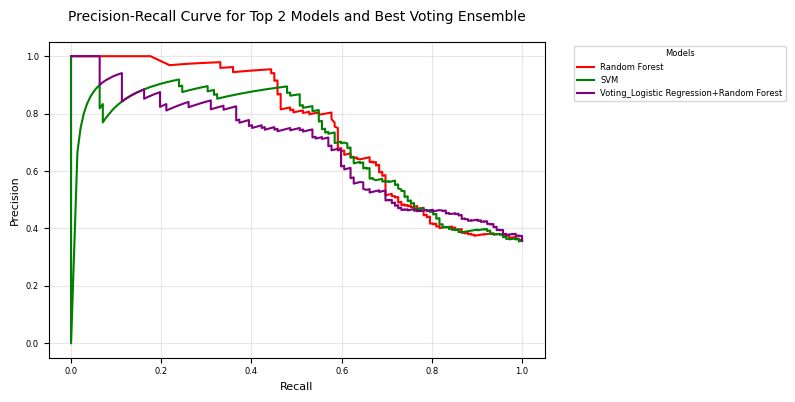

In [35]:
individual_models = ensemble_results_df[
    (~ensemble_results_df['Model'].str.contains('Voting_')) & 
    (ensemble_results_df['Model'] != 'Logistic Regression')
].head(2)  
best_voting = ensemble_results_df[ensemble_results_df['Model'].str.contains('Voting_')].iloc[0]
plt.figure(figsize=(8, 4))

colors = ['red', 'green', 'purple']  
models_to_plot = list(individual_models['Model']) + [best_voting['Model']]

for idx, model_name in enumerate(models_to_plot):
    if 'Voting_' in model_name:
        model = tuned_models[model_name.split('_')[1].split('+')[0]]  
    else:
        model = tuned_models[model_name]
    
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    
    plt.plot(recall, precision, color=colors[idx], label=model_name)

plt.title('Precision-Recall Curve for Top 2 Models and Best Voting Ensemble', fontsize=10, pad=15)
plt.xlabel('Recall', fontsize=8)
plt.ylabel('Precision', fontsize=8)
plt.grid(True, alpha=0.3)
plt.legend(title='Models', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

The precision-recall curve shows that while Random Forest (red) excels at high-confidence predictions (perfect precision at 20% recall), the Voting Ensemble of Logistic Regression+Random Forest (purple) provides more balanced performance. The ensemble maintains better precision across medium to high recall ranges, explaining its superior overall metrics in the results table. This suggests the ensemble is more reliable for travel insurance predictions. 

**5.9 Model Performance**

In [36]:
best_voter = VotingClassifier(
    estimators=[
        ('lr', tuned_models['Logistic Regression']),
        ('rf', tuned_models['Random Forest'])
    ],
    voting='soft'
)

best_voter.fit(X_train, y_train)
y_pred = best_voter.predict(X_test)
y_scores = best_voter.predict_proba(X_test)[:, 1]

test_results = pd.DataFrame([{
    'Model': 'Voting_Logistic Regression+Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred),
    'ROC AUC': roc_auc_score(y_test, y_scores),
    'PR AUC': average_precision_score(y_test, y_scores)
}])

display(test_results.round(2))

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Voting_Logistic Regression+Random Forest,0.79,0.79,0.56,0.65,0.78,0.75


The voting classifier performed slightly better on training data than on unseen test data, as expected. The PR AUC dropped from 0.78 to 0.75, indicating a small reduction in the model's ability to rank positive cases accurately on new data. Overall, the results suggest good generalization with only minor performance degradation.

**5.9.1 Classification Report**

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.92      0.85       256
           1       0.79      0.56      0.65       142

    accuracy                           0.79       398
   macro avg       0.79      0.74      0.75       398
weighted avg       0.79      0.79      0.78       398



The model performs well on class 0 (non-purchasers) with high recall (0.92) and F1 score (0.85), but struggles with class 1 (purchasers), achieving only 0.56 recall and 0.65 F1 score. Although overall accuracy is 0.79, the lower recall for class 1 indicates the model favors predicting non-purchasers and may require further tuning or class rebalancing.

**5.9.2 Confusion Matrix**

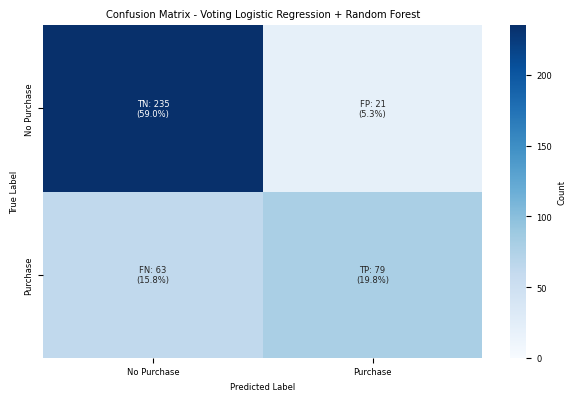

In [38]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
total = np.sum(cm)
tn, fp, fn, tp = cm.ravel()
tn_percent = tn/total * 100
fp_percent = fp/total * 100
fn_percent = fn/total * 100
tp_percent = tp/total * 100

annot = np.array([[f'TN: {tn}\n({tn_percent:.1f}%)', f'FP: {fp}\n({fp_percent:.1f}%)'],
                  [f'FN: {fn}\n({fn_percent:.1f}%)', f'TP: {tp}\n({tp_percent:.1f}%)']])

sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'],
            vmin=0, 
            vmax=max(cm.ravel()),  
            cbar_kws={'label': 'Count'})  

plt.title('Confusion Matrix - Voting Logistic Regression + Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

The confusion matrix shows the model effectively identifies non-purchasers (59%) but struggles with purchasers, correctly predicting only 19.8% and missing 15.8% as false negatives. This highlights a bias toward the majority class and aligns with the earlier low recall for purchasers, suggesting a need for recall-optimised tuning.

**5.9.3 Feature Importance**

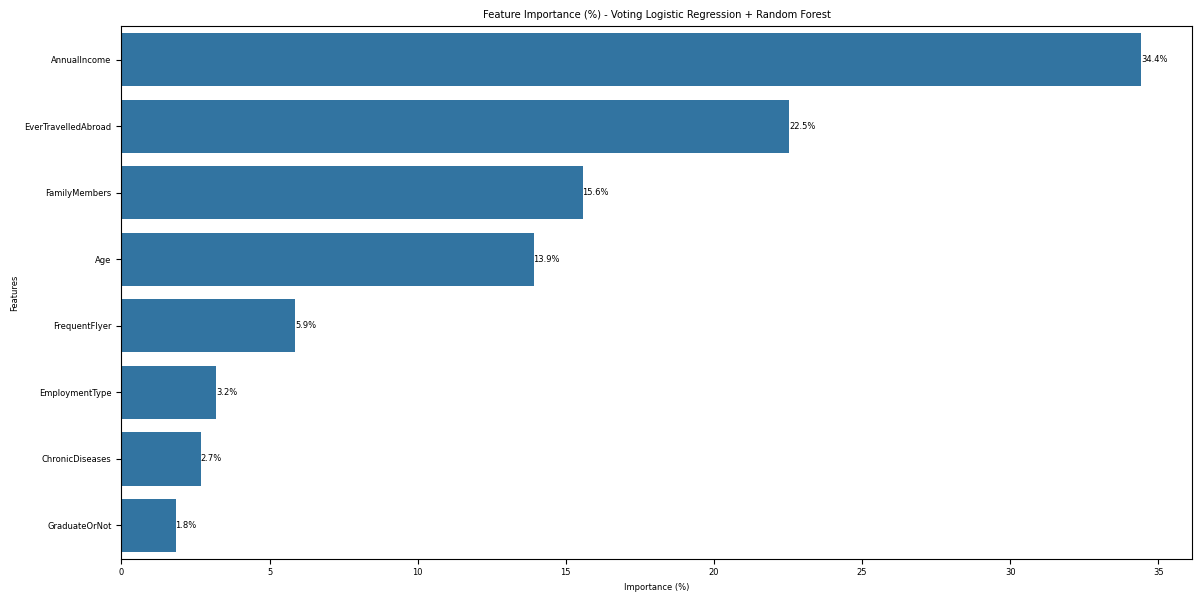

            Feature  Importance (%)
       AnnualIncome           34.41
EverTravelledAbroad           22.53
      FamilyMembers           15.56
                Age           13.91
      FrequentFlyer            5.88
     EmploymentType            3.21
    ChronicDiseases            2.67
      GraduateOrNot            1.83


In [39]:
rf_model = tuned_models['Random Forest'].named_steps['classifier']
lr_model = tuned_models['Logistic Regression'].named_steps['classifier']
rf_importances = rf_model.feature_importances_ * 100
lr_importances = np.abs(lr_model.coef_[0]) / np.sum(np.abs(lr_model.coef_[0])) * 100
combined_importances = (rf_importances + lr_importances) / 2

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance (%)': combined_importances
})

feature_importance = feature_importance.sort_values('Importance (%)', ascending=False).reset_index(drop=True)
plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance, x='Importance (%)', y='Feature')
plt.title('Feature Importance (%) - Voting Logistic Regression + Random Forest')
plt.xlabel('Importance (%)')
plt.ylabel('Features')

for i, v in enumerate(feature_importance['Importance (%)']):
    plt.text(v, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.show()
print(feature_importance.to_string(index=False))

* The feature importance chart shows that AnnualIncome is the most influential predictor of insurance purchase, contributing 34.4% to the model's decisions. This is followed by EverTravelledAbroad (22.5%), FamilyMembers (15.6%), and Age (13.9%), suggesting that financial status, travel history, and family context play key roles in determining purchase behavior. 
* Less influential features include FrequentFlyer, EmploymentType, ChronicDiseases, and GraduateOrNot, each contributing under 6%. These results highlight that socio-economic and lifestyle factors are stronger predictors than education or medical history in this model.


**5.9.4 Precision-Recall Curve for Test Model**

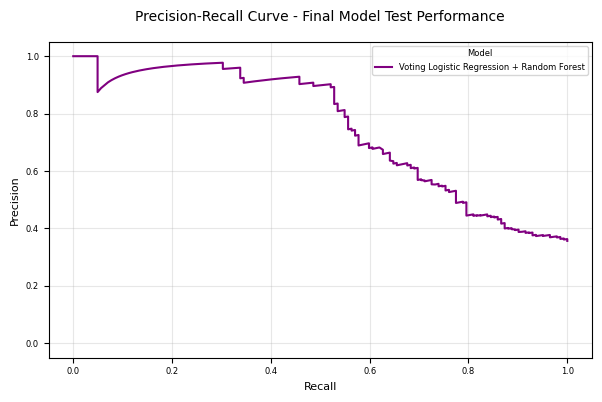

In [40]:
precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color='purple', label='Voting Logistic Regression + Random Forest')

plt.title('Precision-Recall Curve - Final Model Test Performance', fontsize=10, pad=15)
plt.xlabel('Recall', fontsize=8)
plt.ylabel('Precision', fontsize=8)
plt.grid(True, alpha=0.3)
plt.legend(title='Model')

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

The precision-recall curve shows that when the model assigns high probabilities to someone being a purchaser, it is usually correct, this is where precision is highest. As the model lowers its threshold to identify more potential purchasers (increasing recall), it also includes more incorrect predictions, so precision decreases. This trade-off is typical, and the overall curve shows a good balance between precision and recall, matching the PR AUC score of 0.75.

### 6. CONCLUSION & IMPROVEMENTS

**6.1 Conclusions**

* **Model Performance:** The Voting Logistic Regression + Random Forest Model achieved the best overall performance in predicting travel insurance purchases. It achieved the highest balanced PR AUC score. The recommendation is to use this model. 
* **Feature Importance:** The key variables infleuncing travel insurance purchase are Annual Income, Family Members and Age as seen through the feature importance analysis. 
* **Limitations:** The model performs better on identifying non-purchasers than purchasers. 
* **Business Recommendations:** Focus marketing efforts on customers with higher annual income, with international travel experience and consider family size in strategies. 

**6.2 Improvements**

* Consider spending more time on hyperparameter tuning to further enhance the models, especially on recall.  
* Investigate feature importance in the other models (SVM, Logistic Regression and KNN)
* Consider using other ensemble methods. 
* Consider feature engineering or regularisation techniques to lower VIF results. 
* Created a preprocessor pipline including encoding from an earlier stage. 